# DCT Laboratory — Volume I, Chapter 11
## Enterprise Performance Architecture
**Seed `26111`** · Companion to the chapter and AXIOM Module **AXIOM-11**

Three instruments: the **aggregation reversal** (the top-ranked unit is a
property of the weight vector — Performance Aggregation Theorem), the **Pareto
performance frontier** of six units in (cost, quality), and first-order
**performance dynamics** with an explicit half-life.
Mirrored in `DCT_V1_Ch11_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26111
UNITS = ["U1","U2","U3","U4","U5","U6"]
# dims: financial, customer, operational, innovation
S = np.array([
 [82,55,70,40],
 [60,85,65,90],
 [75,70,60,80],
 [50,60,90,45],
 [68,72,75,62],
 [90,40,55,35]], dtype=float)
W1 = np.array([0.70,0.10,0.10,0.10])   # finance-weighted
W2 = np.array([0.05,0.35,0.10,0.50])   # customer/innovation-weighted

# frontier data: (cost, quality) — cost lower-better, quality higher-better
CQ = np.array([[60,70],[45,82],[55,88],[70,90],[50,75],[65,60]], dtype=float)

P0, DRIV, RHO = 50.0, 80.0, 0.8

def composites(w): return S @ w
def pareto_efficient():
    eff = []
    for i,(c,q) in enumerate(CQ):
        dominated = any((CQ[j,0] <= c) and (CQ[j,1] >= q) and (j != i)
                        and ((CQ[j,0] < c) or (CQ[j,1] > q)) for j in range(6))
        eff.append(not dominated)
    return np.array(eff)

def p_path(n=12):
    p = np.empty(n+1); p[0] = P0
    for k in range(n): p[k+1] = RHO*p[k] + (1-RHO)*DRIV
    return p

def reference_values():
    c1, c2 = composites(W1), composites(W2)
    eff = pareto_efficient()
    return {
        "comp_U6_w1": round(float(c1[5]),4), "comp_U2_w1": round(float(c1[1]),4),
        "comp_U2_w2": round(float(c2[1]),4), "comp_U6_w2": round(float(c2[5]),4),
        "top_w1": UNITS[int(np.argmax(c1))], "top_w2": UNITS[int(np.argmax(c2))],
        "n_pareto_efficient": int(eff.sum()),
        "p_at_8": round(float(p_path()[8]),4),
        "half_life": round(float(np.log(2)/np.log(1/RHO)),4),
    }
if __name__ == "__main__":
    [print(f"{k:20s} {v}") for k,v in reference_values().items()]

comp_U6_w1           76.0
comp_U2_w1           66.0
comp_U2_w2           84.25
comp_U6_w2           41.5
top_w1               U6
top_w2               U2
n_pareto_efficient   3
p_at_8               74.9668
half_life            3.1063


## Panel 1 — The aggregation reversal
Six units scored on four dimensions. Weight scheme $w_1$ (finance-heavy) crowns
**U6**; scheme $w_2$ (customer/innovation-heavy) crowns **U2** — with U6 falling
to 41.5. Neither ranking is wrong; each is an *argument made numerical*. The
theorem's demand: publish the weights with the ranking.

In [2]:
c1, c2 = composites(W1), composites(W2)
print(f"{'unit':>5s} {'fin':>5s} {'cust':>5s} {'ops':>5s} {'innov':>6s} | {'w1 comp':>8s} {'w2 comp':>8s}")
for i,u in enumerate(UNITS):
    print(f"{u:>5s} {S[i,0]:5.0f} {S[i,1]:5.0f} {S[i,2]:5.0f} {S[i,3]:6.0f} | {c1[i]:8.2f} {c2[i]:8.2f}")
print(f"\ntop under w1 = {UNITS[np.argmax(c1)]}   top under w2 = {UNITS[np.argmax(c2)]}")

 unit   fin  cust   ops  innov |  w1 comp  w2 comp
   U1    82    55    70     40 |    73.90    50.35
   U2    60    85    65     90 |    66.00    84.25
   U3    75    70    60     80 |    73.50    74.25
   U4    50    60    90     45 |    54.50    55.00
   U5    68    72    75     62 |    68.50    67.10
   U6    90    40    55     35 |    76.00    41.50

top under w1 = U6   top under w2 = U2


## Panel 2 — The performance frontier
The same six units in (cost, quality): three are Pareto-efficient, three are
dominated. The Enterprise Performance Frontier Theorem: improvement without
trade-off exists only for the dominated — on the frontier, every gain in one
dimension is paid for in the other.

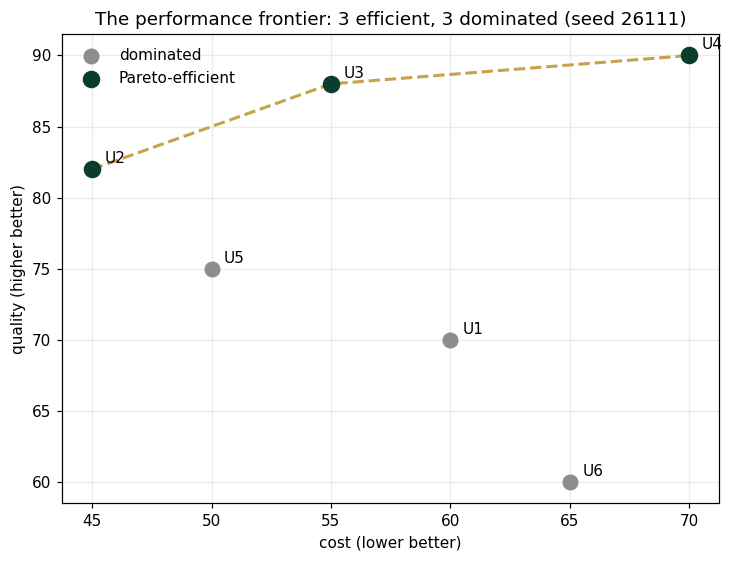

U1: cost   60  quality   70  dominated
U2: cost   45  quality   82  EFFICIENT
U3: cost   55  quality   88  EFFICIENT
U4: cost   70  quality   90  EFFICIENT
U5: cost   50  quality   75  dominated
U6: cost   65  quality   60  dominated


In [3]:
eff = pareto_efficient()
fig, ax = plt.subplots(figsize=(6.8,5.2))
front = CQ[eff][np.argsort(CQ[eff][:,0])]
ax.plot(front[:,0], front[:,1], c="#C8A24B", lw=2, ls="--", zorder=1)
ax.scatter(CQ[~eff,0], CQ[~eff,1], c="#8A8F8B", s=90, label="dominated", zorder=2)
ax.scatter(CQ[eff,0], CQ[eff,1], c="#0B3D2E", s=110, label="Pareto-efficient", zorder=3)
for i,u in enumerate(UNITS):
    ax.annotate(u, CQ[i], textcoords="offset points", xytext=(8,4), fontsize=10)
ax.set(xlabel="cost (lower better)", ylabel="quality (higher better)",
       title="The performance frontier: 3 efficient, 3 dominated (seed 26111)")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
for u,(c,q),e in zip(UNITS, CQ, eff):
    print(f"{u}: cost {c:4.0f}  quality {q:4.0f}  {'EFFICIENT' if e else 'dominated'}")

## Panel 3 — Performance dynamics
Performance responds to its drivers with inertia: $p_{k+1} = \rho p_k +
(1-\rho)d$ with $\rho = 0.8$. The gap to the driver level halves every
$\ln 2 / \ln(1/\rho) = 3.11$ quarters — Performance Evolves Dynamically
(Prop.), with a number attached: today's initiative reads in the metrics three
quarters later.

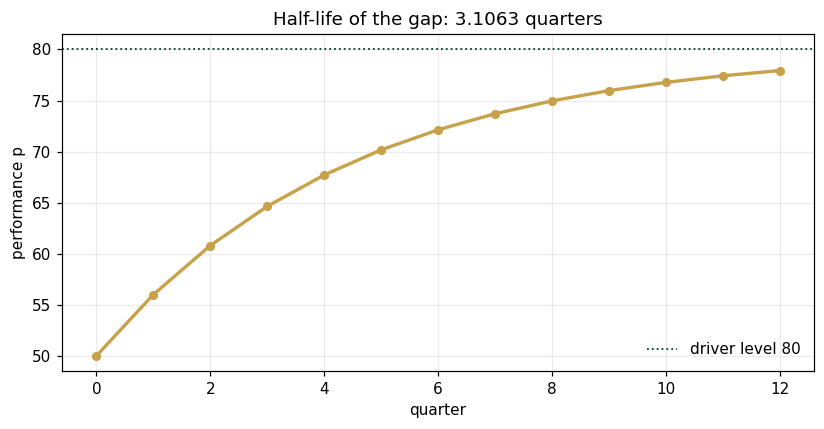

p at k=8: 74.9668   half-life: 3.1063 quarters


In [4]:
p = p_path()
t = np.arange(len(p))
fig, ax = plt.subplots(figsize=(7.6,4.0))
ax.plot(t, p, "o-", c="#C8A24B", lw=2.2, ms=5)
ax.axhline(DRIV, c="#0B3D2E", ls=":", lw=1.2, label=f"driver level {DRIV:.0f}")
ax.set(xlabel="quarter", ylabel="performance p", title=f"Half-life of the gap: {np.log(2)/np.log(1/RHO):.4f} quarters")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"p at k=8: {p[8]:.4f}   half-life: {np.log(2)/np.log(1/RHO):.4f} quarters")

## Validation — agrees with `DCT_V1_Ch11_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"comp_U6_w1":76.0,"comp_U2_w1":66.0,"comp_U2_w2":84.25,"comp_U6_w2":41.5,
 "n_pareto_efficient":3,"p_at_8":74.9668,"half_life":3.1063}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:20s} {ref[k]}")
assert ref["top_w1"]=="U6" and ref["top_w2"]=="U2"
print("PASS  ranking reversal      U6 (w1) → U2 (w2)")
print("\nAll checkpoints agree — seed 26111.")

PASS  comp_U6_w1           76.0
PASS  comp_U2_w1           66.0
PASS  comp_U2_w2           84.25
PASS  comp_U6_w2           41.5
PASS  n_pareto_efficient   3
PASS  p_at_8               74.9668
PASS  half_life            3.1063
PASS  ranking reversal      U6 (w1) → U2 (w2)

All checkpoints agree — seed 26111.


**Next**: Exercises 11.9–11.12 (Part C) rebuild the frontier with your own weights; AXIOM-11's weighting console animates the reversal. Solutions: IM Ch. 11.